# Dimensionality Figure

This notebook computes and visualizes **population dimensionality (D$_{PR}$)** and the **eigenvalue spectrum** of connectivity matrices for networks with varying QIF-neuron fraction (p$_{QIF}$), across two target dynamics: *oscillations* and *sequences*.

---

## 1. Imports

In [4]:
import os
import pickle
import matplotlib
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.legend_handler import HandlerTuple



# Path to simulation files

In [5]:
from pathlib import Path
base_path = Path(r"J:\ordinary_simulations") 
base_path.mkdir(parents=True, exist_ok=True)

## 2. Figure Style

Global matplotlib settings

In [6]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    "figure.figsize": (16, 6)       # Figsize
    # "figure.figsize": (8, 6)       # Figsize
})

plt.rcParams['svg.fonttype'] = 'none'
plt.matplotlib.rcParams['image.composite_image'] = False

## 3. Output Folders

Creates the `oscillations/` and `sequences/` directories if they don't already exist. These hold the simulation CSV outputs read throughout this notebook.

In [7]:
oscillations_folder = 'oscillations'
if not os.path.exists(oscillations_folder):
    os.makedirs(oscillations_folder)
sequences_folder = 'sequences'
if not os.path.exists(sequences_folder):
    os.makedirs(sequences_folder)

## 4. Global Parameters

Simulation parameters shared across all analyses:
- **`N = 200`** neurons, **`itmax = 2000`** timesteps, **`itstim = 200`** stimulus onset
- **p$_{QIF}$ sweep**: `[0, 0.25, 0.5, 0.75, 1]` — fraction of QIF neurons in the network
- **`v_rest` levels**: `[-22, -17, -12.3, -8.5]` mV — resting potentials defining LIF neuron subtypes
- A `plt.cm.Reds` colormap color-codes `v_rest` levels consistently across all plots

In [8]:
names = ['LIF', 'MIX', 'QIF']
colors = ['firebrick', 'forestgreen', 'steelblue']


N = 200
itmax = 2000
itstim = 200 
nloop = 16

pqif_vector      = [0, 0.25, 0.5, 0.75, 1]
points_per_window = 10
cant_seed         = 50 # change according to seeds used
iloop             = 11

v_rest = [-22, -17, -12.3, -8.5]
cmap = plt.cm.Reds
vrest_sorted = sorted(v_rest)
colors_sorted = [cmap(x) for x in np.linspace(0.25, 1, len(v_rest))]
color_map = {vr: c for vr, c in zip(vrest_sorted, colors_sorted)}




## 5. Helper Functions I —  D$_{PR}$

### `dpr_bias`
Computes the bias-corrected **Population Dimensionality (D$_{PR}$)** from a cross-correlation matrix. Applies separate corrections to the diagonal (auto-correlations) and off-diagonal (cross-correlations) entries.

In [9]:
def dpr_bias(ccorr, N, nloop):
    a = np.extract(np.identity(N), ccorr)
    c = np.extract(1-np.identity(N), ccorr)
    am2 = np.mean(a)**2
    astd2 = np.var(a)*N/(N-1)
    cm2 = np.mean(c)**2
    cstd2 = np.var(c)*N*(N-1)/(N*(N-1)-2)

    astd_bias2 = astd2*(nloop-1)/(nloop+1) - 2*(am2-cm2) / \
        (nloop-1) + 2*cstd2/(nloop+1)
    cstd_bias2 = (nloop-1)*cstd2/nloop - (am2-cm2)/nloop - \
        4*(cm2-np.sqrt(am2*cm2))/(nloop*(N+1))

    dpr_bias = N/(1+(astd_bias2/am2)+(N-1)*((cstd_bias2/am2)+(cm2/am2)))

    return dpr_bias, am2, cm2, astd2, cstd2

## 6. Helper Functions II — Path Resolution

### `get_paths`
Resolves all file paths (outputs, inputs, targets, parameters, connectivity matrices) for a given simulation index, p$_{QIF}$ value, loop, and seed. Handles the different directory conventions used by *oscillations* vs *sequences* experiments.

In [25]:
from pathlib import Path
base_path = Path(r"J:\ordinary_simulations") 
base_path.mkdir(parents=True, exist_ok=True)

def get_paths(folders, target, idx, pqif, iloop, seed):
    folder = folders[target]  # oscillations or sequence folder
    base_path = Path(r"J:\ordinary_simulations") 
    base_path.mkdir(parents=True, exist_ok=True)
    # Martina
    # if target == 'oscillations':
    #     sim  = f'simulation_{idx}'
    #     base = os.path.join(folder, sim)
    #     out  = os.path.join(base, f'{sim}_outputs', f'{sim}_outputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
    #     inp  = os.path.join(base, f'{sim}_inputs',  f'{sim}_inputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
    #     tgt  = os.path.join(base, f'{sim}_targets_{pqif}.csv')
    #     par  = os.path.join(base, f'{sim}_parameters.csv')
    #     mat  = os.path.join(base, f'{sim}_connectivity_matrix',
    #                         f'{sim}_connectivity_pqif_{pqif}_iloop_{iloop}_seed_{seed}')
        
    # Martina
    # else: #for sequences, the paths are different from oscillations
    #     sim  = f'simulacion_{idx}'
    #     base = os.path.join(folder, sim)
    #     out  = os.path.join(base, 'omega_0.1', 'outputs', f'outputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
    #     inp  = os.path.join(base, 'omega_0.1', 'inputs',  f'inputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
    #     tgt  = os.path.join(base, f'simulation_{idx}_targets_{pqif}.csv')
    #     par  = os.path.join(base, f'{sim}_parametros.csv')
    #     mat  = os.path.join(base, 'omega_0.1', 'matrices_pesos',
    #                         f'pesos_pqif_{pqif}_matriz_iloop_{iloop}_semilla_{seed}')
        

    # Neneva
    if target == 'oscillations':
        sim  = f'simulation_{idx}'
        base = os.path.join(base_path, sim)
        out  = os.path.join(base, f'{sim}_outputs', f'{sim}_outputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
        inp  = os.path.join(base, f'{sim}_inputs',  f'{sim}_inputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
        tgt  = os.path.join(base, f'{sim}_targets',  f'{sim}_targets_pqif{pqif}_seed_{seed}.csv')  # should retrieve target, and these were saved without the underscore
        par  = os.path.join(base, f'{sim}_parameters.csv')
        mat  = os.path.join(base, f'{sim}_connectivity_matrix',
                            f'{sim}_connectivity_pqif_{pqif}_iloop_{iloop}_seed_{seed}')
    else: #for sequences, the paths are different from oscillations
        sim  = f'simulation_{idx}'
        base = os.path.join(base_path, sim)
        out  = os.path.join(base, f'{sim}_outputs', f'{sim}_outputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
        inp  = os.path.join(base, f'{sim}_inputs',  f'{sim}_inputs_pqif_{pqif}_iloop_{iloop}_seed_{seed}.csv')
        tgt  = os.path.join(base, f'simulation_{idx}_targets_{pqif}.csv')
        par  = os.path.join(base, f'{sim}_parameters.csv')
        mat  = os.path.join(base, f'{sim}_connectivity_matrix',
                            f'{sim}_connectivity_pqif_{pqif}_iloop_{iloop}_seed_{seed}')
    return out, inp, tgt, par, mat

## 7. Helper Functions III — Plotting

### `plot_dpr_inputs_saved` / `plot_dpr_outputs_saved`
Plot D$_{PR}$ of the synaptic drive (inputs) and filtered spike trains (outputs) as a function of p$_{QIF}$, with error bars. Each `v_rest` level is shown in a distinct Red shade; the target D$_{PR}$ is overlaid as a purple dashed line.

### `plot_spectrum`
Scatters the real and imaginary parts of the connectivity matrix eigenvalues for p$_{QIF}$ ∈ {0, 0.5, 1}, color-coded by network composition.

### `make_square_ax`
Creates a visually square subplot within a GridSpec cell using a 3-column sub-grid.

In [26]:
def plot_dpr_inputs_saved(ax, saved_data, target):
    pqif_used = saved_data[target]['pqif_used']
    # Target is the same across vrest values; take the first available key
    first_vr    = next(iter(saved_data[target]['DPR_tgt_mean']))
    tgt_means   = saved_data[target]['DPR_tgt_mean'][first_vr]
    tgt_stds    = saved_data[target]['DPR_tgt_std'][first_vr]

    for vr in vrest_sorted:
        means = saved_data[target]['DPR_in_mean'].get(vr, [np.nan] * len(pqif_used))
        stds  = saved_data[target]['DPR_in_std'].get(vr,  [np.nan] * len(pqif_used))
        pqif_rest = [pq for pq in pqif_used if pq != 1]
        ax.errorbar(pqif_rest,
                    [means[i] for i, pq in enumerate(pqif_used) if pq != 1],
                    yerr=[stds[i] for i, pq in enumerate(pqif_used) if pq != 1],
                    fmt='o-', color=color_map[vr], label=f'$V_r$={vr}', markersize=4)
        ax.errorbar(1, means[-1], yerr=stds[-1], fmt='o', color='steelblue', markersize=4)
    # DPR target: one point per pqif with std
    ax.errorbar(pqif_used, tgt_means, yerr=tgt_stds,
                fmt='--', color='purple', markersize=4, linewidth=0.75, label='DPR target')
    ax.set_xlabel(r'p$_{\mathrm{QIF}}$')
    ax.set_ylabel(r'D$_{\mathrm{PR}}$')
    ax.set_title('Synaptic drive', fontsize=11, pad=4)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])


def plot_dpr_outputs_saved(ax, saved_data, target):
    pqif_used = saved_data[target]['pqif_used']
    # Target is the same across vrest values; take the first available key
    first_vr  = next(iter(saved_data[target]['DPR_tgt_mean']))
    tgt_means = saved_data[target]['DPR_tgt_mean'][first_vr]
    tgt_stds  = saved_data[target]['DPR_tgt_std'][first_vr]

    for vr in vrest_sorted:
        means = saved_data[target]['DPR_out_mean'].get(vr, [np.nan] * len(pqif_used))
        stds  = saved_data[target]['DPR_out_std'].get(vr,  [np.nan] * len(pqif_used))
        pqif_rest = [pq for pq in pqif_used if pq != 1]
        ax.errorbar(pqif_rest,
                    [means[i] for i, pq in enumerate(pqif_used) if pq != 1],
                    yerr=[stds[i] for i, pq in enumerate(pqif_used) if pq != 1],
                    fmt='o-', color=color_map[vr], label=f'$V_r$={vr}', markersize=4)
        ax.errorbar(1, means[-1], yerr=stds[-1], fmt='o', color='steelblue', markersize=4)
    # DPR target: one point per pqif with std
    ax.errorbar(pqif_used, tgt_means, yerr=tgt_stds,
                fmt='--', color='purple', markersize=4, linewidth=0.75)
    ax.set_xlabel(r'p$_{\mathrm{QIF}}$')
    ax.set_ylabel(r'D$_{\mathrm{PR}}$')
    ax.set_title('Filtered spike train', fontsize=11, pad=4)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])

def plot_spectrum(ax, folders, target, idx, pqif_vector_spec, iloop):
    # Load simulation parameters to get vrest
    _, _, _, par_path, _ = get_paths(folders, target, idx, pqif=0, iloop=iloop, seed=0)
    vrest_sim = pd.read_csv(par_path)['vrest'].values[0]

    for pqif in pqif_vector_spec:
        # Color scheme: vrest color for pqif=0, green for 0.5, blue otherwise
        color = {0: color_map[vrest_sim], 0.5: 'forestgreen'}.get(pqif, 'steelblue')

        _, _, _, _, mat_path = get_paths(folders, target, idx, pqif, iloop, seed=0)
        matrix  = pd.read_csv(mat_path, header=None).values
        eigvals, _ = np.linalg.eig(matrix)
        ax.scatter(np.real(eigvals), np.imag(eigvals),
                   color=color, alpha=0.6, s=6, edgecolors='none')

    lim = 17 if target == 'oscillations' else 10
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'Re($\lambda$)')
    ax.set_ylabel(r'Im($\lambda$)')


def make_square_ax(fig, gs_cell):
    """Centered square axis within a gridspec cell, visually equivalent to set_box_aspect(1)."""
    sub = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=gs_cell,
        width_ratios=[0.35, 2, 0.35], wspace=0.0
    )
    ax = fig.add_subplot(sub[0, 1])
    ax.set_box_aspect(1)
    return ax


## 8. Computation Functions

### `compute_dpr_from_path`
Reads a CSV, trims the pre-stimulus period, reshapes into non-overlapping windows of `points_per_window` steps, averages population activity per window, and returns the bias-corrected D$_{PR}$.

### `compute_pearson_per_neuron`
For each neuron, computes the Pearson correlation between the target signal and the input/output signals (post-stimulus). Returns the mean correlation across all neurons.

### `aggregate_stats`
Aggregates per-p$_{QIF}$ value lists into mean ± std, skipping empty entries.

In [27]:
def compute_dpr_from_path(path, itstim, points_per_window, N, header=None):
    """Read a CSV, trim, reshape into windows, and return the DPR."""
    data = pd.read_csv(path, header=header).values
    data = data[itstim:]
    n_w  = data.shape[0] // points_per_window
    data = data[:n_w * points_per_window].reshape(n_w, points_per_window, N)
    rprom = np.mean(data, axis=1).T
    cov   = np.cov(rprom, rowvar=True, bias=False)
    dpr, *_ = dpr_bias(cov, N=N, nloop=rprom.shape[1])
    return dpr


def compute_pearson_per_neuron(targets_arr, inputs_arr, outputs_arr, itstim, N):
    """Mean Pearson correlation across neurons for inputs and outputs against the target."""
    t = targets_arr[itstim:]
    ci_in  = np.zeros(N)
    ci_out = np.zeros(N)
    for i in range(N):
        if np.var(t[:, i]) > 0:
            if np.var(inputs_arr[itstim:, i]) > 0:
                ci_in[i]  = pearsonr(t[:, i], inputs_arr[itstim:,  i])[0]
            if np.var(outputs_arr[itstim:, i]) > 0:
                ci_out[i] = pearsonr(t[:, i], outputs_arr[itstim:, i])[0]
    return np.mean(ci_in), np.mean(ci_out)


def aggregate_stats(values_dict, pqif_vector):
    """Mean and std per pqif value, skipping entries with no data."""
    pqif_used = [pq for pq in pqif_vector if len(values_dict[pq]) > 0]
    means = [np.mean(values_dict[pq]) for pq in pqif_used]
    stds  = [np.std(values_dict[pq])  for pq in pqif_used]
    return pqif_used, means, stds
 

## 9. Data Aggregation Loop

Iterates over both target types and all `v_rest` / seed combinations. For each simulation:
1. Loads parameters to identify the `v_rest` value
2. Computes D$_{PR}$ for outputs, inputs, and targets across all p$_{QIF}$ levels
3. Computes mean Pearson correlation between output/input signals and the target
4. Aggregates results (mean ± std) per `v_rest`

All results are stored in the `saved` dictionary, keyed by target type.

In [36]:
folders = {
    'oscillations': oscillations_folder,
    'sequences':    sequences_folder,
}

saved = {}

for target in ['oscillations', 'sequences']:
    if target == 'sequences':
        print(idx)

  
    # Collect metrics across all idx (one per vrest value)

    all_stats = {
        key: {} for key in
        ['DPR_out_mean', 'DPR_out_std',
         'DPR_in_mean',  'DPR_in_std',
         'DPR_tgt_mean', 'DPR_tgt_std',
         'Pout_mean',    'Pout_std',
         'Pin_mean',     'Pin_std']
    }

    DPR_target_all = {pq: [] for pq in pqif_vector}

    simulation_number = [i for i in range(1,5)] if target == 'oscillations' else [i for i in range(9,13)]

    # for idx in range(1, cant_seed + 1):
    for idx in simulation_number:

        _, _, _, par_path, _ = get_paths(folders, target, idx, pqif=pqif_vector[0], iloop=iloop, seed=0)
        print(par_path)
        vrest_val = pd.read_csv(par_path)['vrest'].values[0]

        # Make containers for all pqif
        DPR_outputs  = {pq: [] for pq in pqif_vector}
        DPR_inputs   = {pq: [] for pq in pqif_vector}
        DPR_targets  = {pq: [] for pq in pqif_vector}
        Pearson_outputs = {pq: [] for pq in pqif_vector}
        Pearson_inputs  = {pq: [] for pq in pqif_vector}

        for pqif in pqif_vector:
            _, _, tgt_path, _, _ = get_paths(folders, target, idx, pqif, iloop, seed=0)

            print(tgt_path)
            targets_pqif = pd.read_csv(tgt_path).values  # Reads values from target file for current (sim, pqif)

            # DPR of the target for this idx and pqif
            dpr_tgt = compute_dpr_from_path(tgt_path, itstim, points_per_window, N, header=0)
            DPR_targets[pqif].append(dpr_tgt)
            DPR_target_all[pqif].append(dpr_tgt)

            for seed in range(cant_seed):
                out_path, in_path, _, _, _ = get_paths(folders, target, idx, pqif, iloop, seed)

                if not os.path.exists(out_path) or not os.path.exists(in_path):
                    continue

                DPR_outputs[pqif].append(
                    compute_dpr_from_path(out_path, itstim, points_per_window, N)
                )
                DPR_inputs[pqif].append(
                    compute_dpr_from_path(in_path,  itstim, points_per_window, N)
                )

                inputs_arr  = pd.read_csv(in_path,  header=None).values
                outputs_arr = pd.read_csv(out_path, header=None).values
                pi, po = compute_pearson_per_neuron(targets_pqif, inputs_arr, outputs_arr, itstim, N)
                Pearson_inputs[pqif].append(pi)
                Pearson_outputs[pqif].append(po)

        # Aggregate mean and std per vrest
        pqif_used, dpr_out_m, dpr_out_s = aggregate_stats(DPR_outputs,     pqif_vector)
        _,         dpr_in_m,  dpr_in_s  = aggregate_stats(DPR_inputs,      pqif_vector)
        _,         dpr_tgt_m, dpr_tgt_s = aggregate_stats(DPR_targets,     pqif_vector)
        _,         po_m,      po_s      = aggregate_stats(Pearson_outputs,  pqif_vector)
        _,         pi_m,      pi_s      = aggregate_stats(Pearson_inputs,   pqif_vector)

        all_stats['DPR_out_mean'][vrest_val] = dpr_out_m
        all_stats['DPR_out_std'][vrest_val]  = dpr_out_s
        all_stats['DPR_in_mean'][vrest_val]  = dpr_in_m
        all_stats['DPR_in_std'][vrest_val]   = dpr_in_s
        all_stats['DPR_tgt_mean'][vrest_val] = dpr_tgt_m
        all_stats['DPR_tgt_std'][vrest_val]  = dpr_tgt_s
        all_stats['Pout_mean'][vrest_val]    = po_m
        all_stats['Pout_std'][vrest_val]     = po_s
        all_stats['Pin_mean'][vrest_val]     = pi_m
        all_stats['Pin_std'][vrest_val]      = pi_s

    # ------------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------------
    saved[target] = {
        'pqif_used': pqif_used,
        **all_stats,
    }

J:\ordinary_simulations\simulation_1\simulation_1_parameters.csv
J:\ordinary_simulations\simulation_2\simulation_2_parameters.csv
J:\ordinary_simulations\simulation_3\simulation_3_parameters.csv
J:\ordinary_simulations\simulation_4\simulation_4_parameters.csv
4
J:\ordinary_simulations\simulation_9\simulation_9_parameters.csv
J:\ordinary_simulations\simulation_9\simulation_9_targets_0.csv
J:\ordinary_simulations\simulation_9\simulation_9_targets_0.25.csv
J:\ordinary_simulations\simulation_9\simulation_9_targets_0.5.csv
J:\ordinary_simulations\simulation_9\simulation_9_targets_0.75.csv
J:\ordinary_simulations\simulation_9\simulation_9_targets_1.csv
J:\ordinary_simulations\simulation_10\simulation_10_parameters.csv
J:\ordinary_simulations\simulation_10\simulation_10_targets_0.csv
J:\ordinary_simulations\simulation_10\simulation_10_targets_0.25.csv
J:\ordinary_simulations\simulation_10\simulation_10_targets_0.5.csv
J:\ordinary_simulations\simulation_10\simulation_10_targets_0.75.csv
J:\ord

## 10. Save and Reload Aggregated Data

Serializes the `saved` dictionary to `dimensionality_data.pkl` with `pickle`, then immediately reloads it. This checkpoint allows iterating on the figure without re-running the full aggregation loop.

In [37]:
with open('dimensionality_data.pkl', 'wb') as f:
    pickle.dump(saved, f)

# Load in the plot cell
with open('dimensionality_data.pkl', 'rb') as f:
    saved = pickle.load(f)

## 11. Figure Assembly

Builds a **3×2 panel figure** (4.5 × 7 in):

| Row | Content |
|-----|---------|
| 0   | D$_{PR}$ of **filtered spike train** (outputs) vs p$_{QIF}$ |
| 1   | D$_{PR}$ of **synaptic drive** (inputs) vs p$_{QIF}$ |
| 2   | **Eigenvalue spectrum** of connectivity matrix |

Columns correspond to *oscillations* (left) and *sequences* (right). Y-axis range is shared between the input and output D$_{PR}$ panels for each target. Saved as `dpr_pearson_spectrum.svg`.

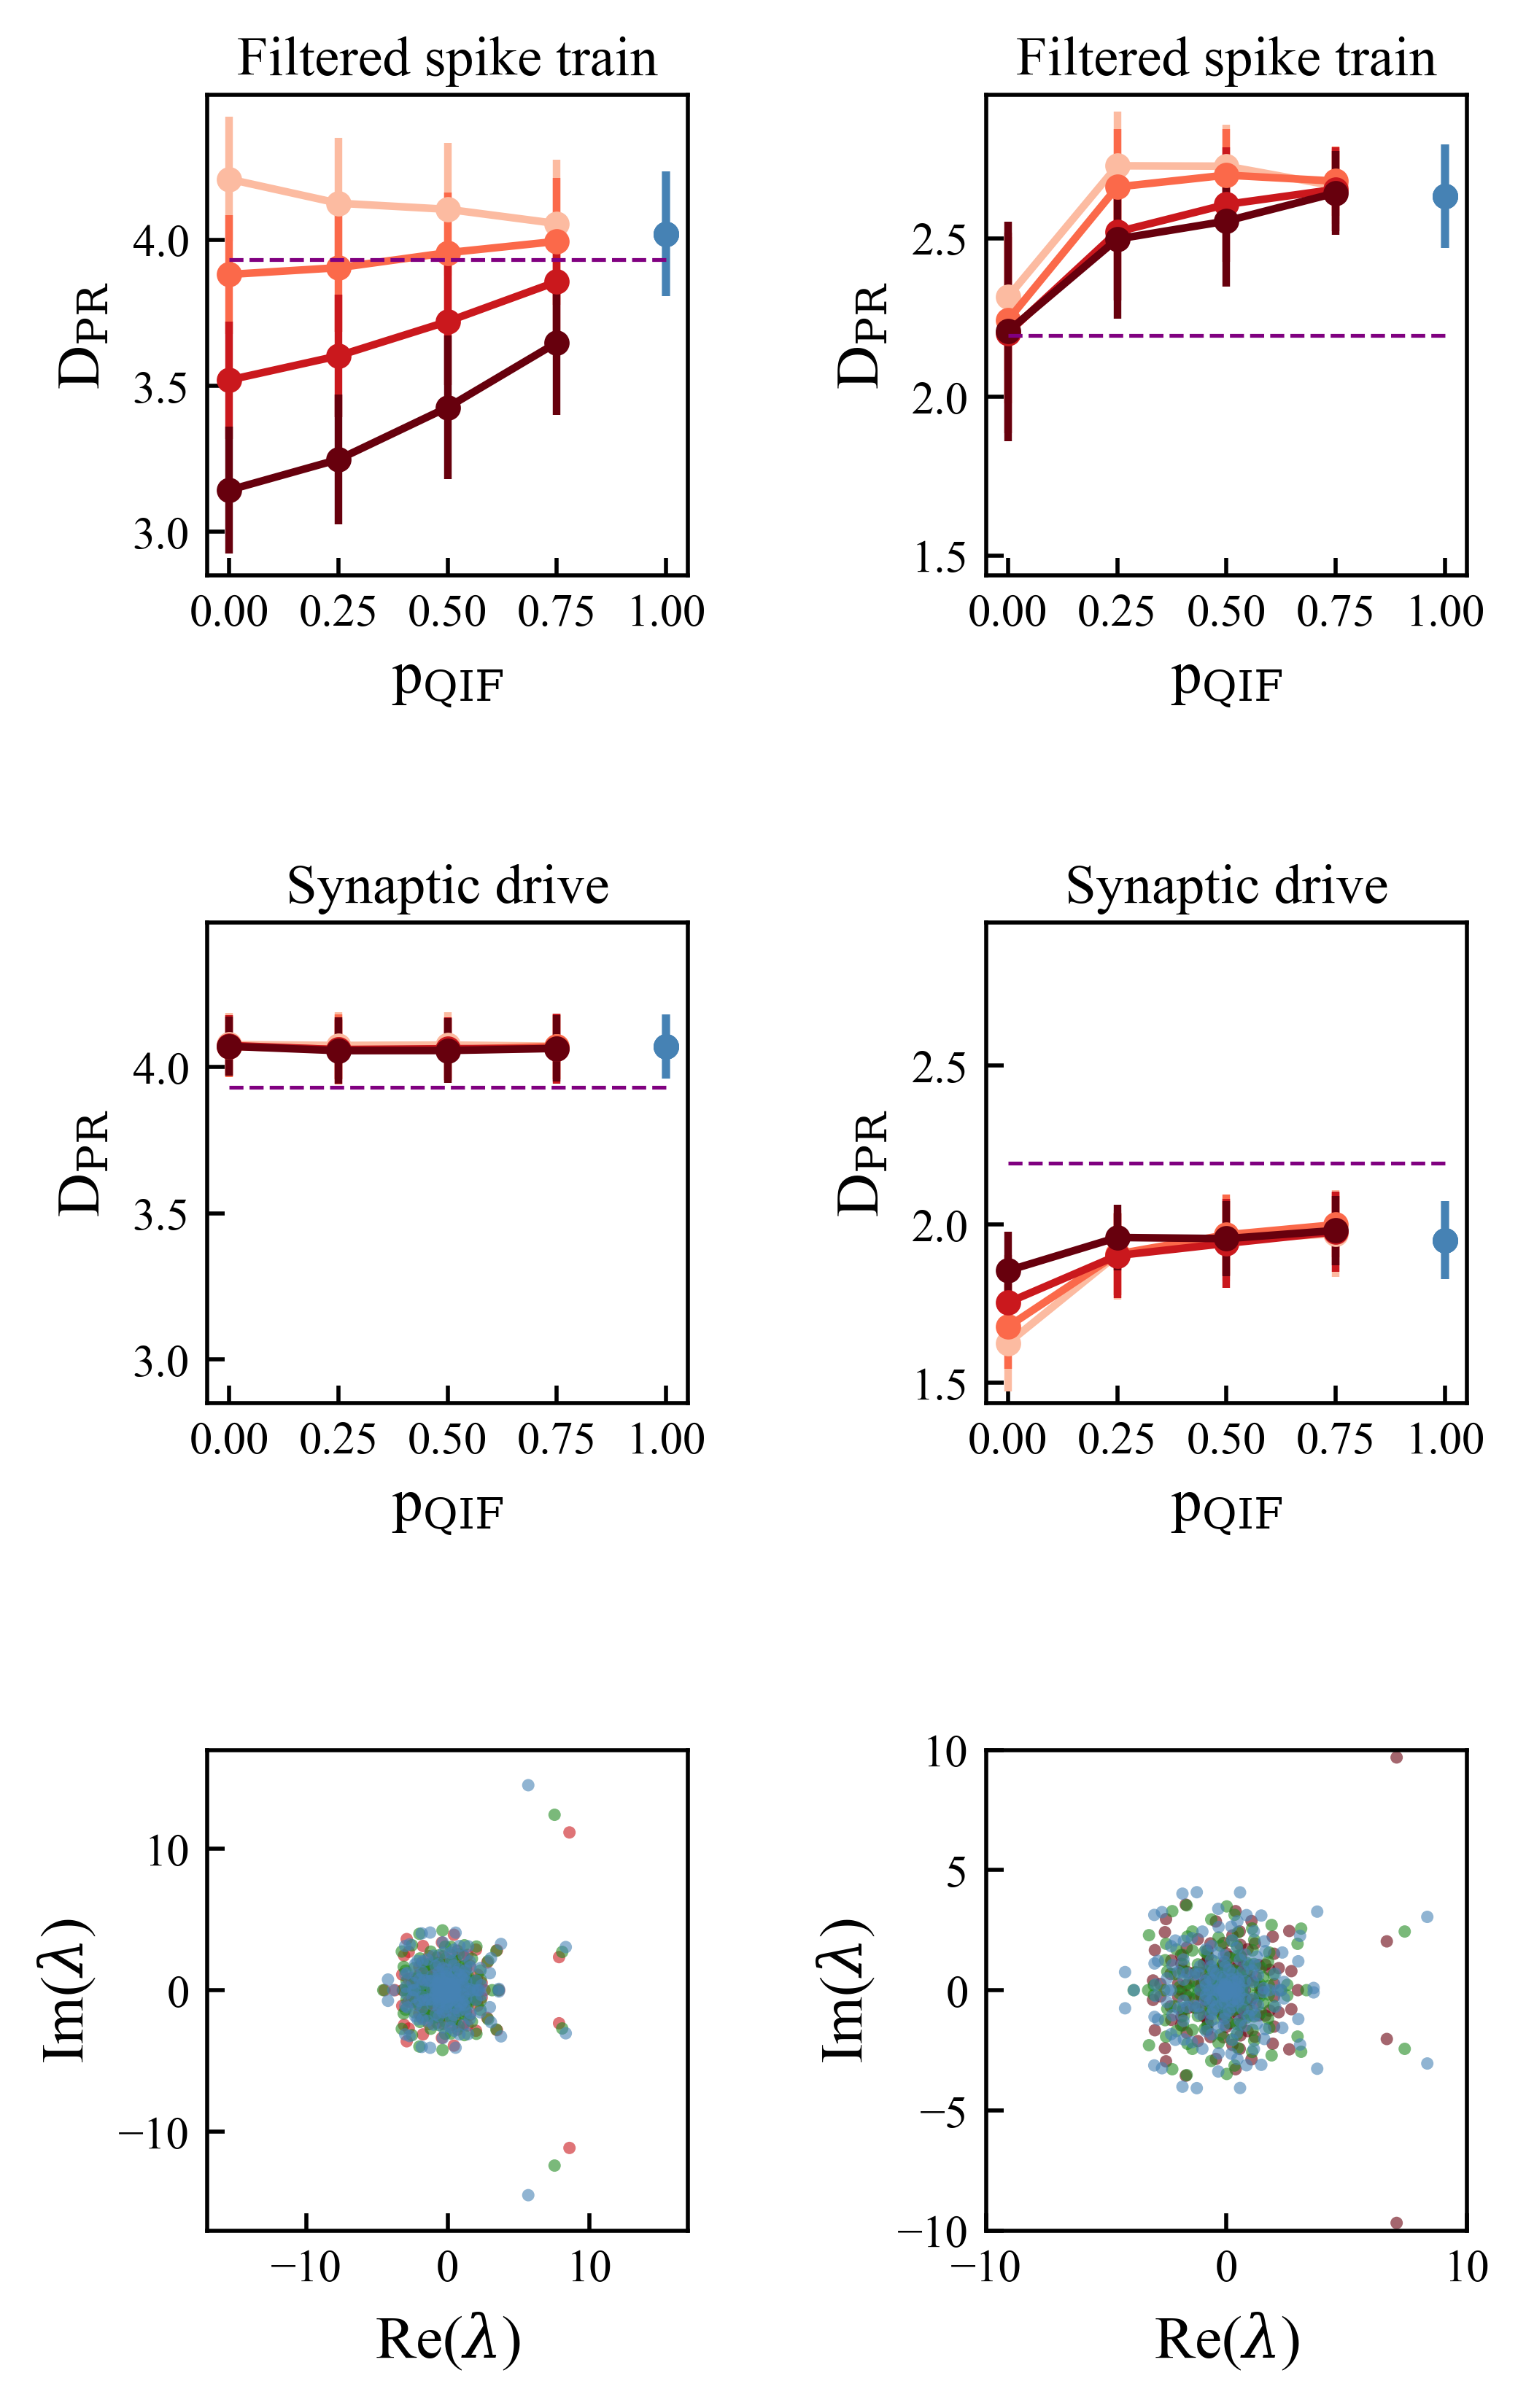

In [38]:
fig = plt.figure(figsize=(4.5, 7))
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1, 1, 1],
    left=0.10, right=0.97,
    bottom=0.06, top=0.94,
    wspace=0.2,
    hspace=0.4,
)

axes_dict = {}


targets = ['oscillations', 'sequences']

for col, target in enumerate(targets):
    axes_dict[(target, 'dpr_out')]  = make_square_ax(fig, gs[0, col])  # fila 0
    axes_dict[(target, 'dpr_in')]   = make_square_ax(fig, gs[1, col])  # fila 1
    axes_dict[(target, 'spectrum')] = make_square_ax(fig, gs[2, col])  # fila 2



for target in targets:
    plot_dpr_inputs_saved (axes_dict[(target, 'dpr_in')],  saved, target)
    plot_dpr_outputs_saved(axes_dict[(target, 'dpr_out')], saved, target)
    idx_spectrum = 2 if target == 'oscillations' else 1  
    plot_spectrum         (axes_dict[(target, 'spectrum')], folders, target,
                           idx=idx_spectrum, pqif_vector_spec=[0, 0.5, 1], iloop=iloop)

# ── Share scale for inputs and outputs for a given target ───────────────
for target in targets:
    ax_in  = axes_dict[(target, 'dpr_in')]
    ax_out = axes_dict[(target, 'dpr_out')]

    ymin = min(ax_in.get_ylim()[0], ax_out.get_ylim()[0])
    ymax = max(ax_in.get_ylim()[1], ax_out.get_ylim()[1])
    ax_in.set_ylim(ymin, ymax)
    ax_out.set_ylim(ymin, ymax)

    xmin = min(ax_in.get_xlim()[0], ax_out.get_xlim()[0])
    xmax = max(ax_in.get_xlim()[1], ax_out.get_xlim()[1])
    ax_in.set_xlim(xmin, xmax)
    ax_out.set_xlim(xmin, xmax)
plt.savefig('dpr_pearson_spectrum.svg')
plt.show()